# Paso 3: Verificacion y resultados de la tesis

**Orden:** Ejecutar despues del **Paso 2** (Notebook 02). Este notebook contiene: (1) Figuras 3D para el paper (proteínas 1A4I y 5IUS desde backend OVO), (2) Modulo de verificacion: tablas por pool, metricas y resultados de los 361 disenos.

## Parte A: Figuras 3D (Figura 2 del paper)

### Panel (a): Oxidoreductasa 1A4I
Sitio activo: **residuos 56, 100 y 125**. Motivo fijo para scaffold design con RFdiffusion.

### Panel (d): Interfaz PD-1/PD-L1 5IUS
Segmentos **63-82 y 119-140** de la cadena A. Motivo fijo para scaffolds que preservan la interfaz.

Los PDB se leen desde **ovo_home/inputs/** (backend OVO). Visualizacion 3D completa con Mol* en la app OVO (http://localhost:8501).

## Parte B: Verificacion de resultados

Al final del notebook: tablas por pool (aceptados/totales), metricas clave (PAE, pLDDT, RMSD, ddG) y graficos de verificacion desde el backend OVO.

## Paso 0: Configurar OVO_HOME (backend OVO)

Este notebook usa el **backend de OVO** como fuente de datos: los archivos PDB se leen desde `ovo_home/inputs/` cuando existen (oxidoreductase, pd1, insulin). La visualización 3D completa con Mol* está disponible en la app OVO (http://localhost:8501).

In [8]:
import os

def _find_ovo_home():
    cwd = os.getcwd()
    for base in [cwd, os.path.join(cwd, "..", ".."), os.path.join(cwd, "..", "..", "..")]:
        for rel in ["ovo_home", os.path.join("..", "ovo_home"), os.path.join("..", "..", "ovo_home")]:
            p = os.path.abspath(os.path.join(base, rel))
            if os.path.exists(p) and os.path.exists(os.path.join(p, "config.yml")):
                return p
    return None

OVO_HOME = os.environ.get("OVO_HOME") or _find_ovo_home()
if OVO_HOME:
    os.environ["OVO_HOME"] = OVO_HOME
    print("OVO_HOME (backend OVO):", OVO_HOME)
else:
    print("AVISO: OVO_HOME no definido. Los PDB se descargaran desde RCSB.")

OVO_HOME (backend OVO): d:\ProyectosUniversidad\BioInformatica\ovo_home


## Paso 1: Detectar entorno (Colab vs. local)

py3Dmol es la libreria que permite visualizar estructuras 3D de proteinas directamente en Jupyter. En Google Colab necesita instalarse; en local ya deberia estar disponible.

In [9]:
# --- Ejecutar en Google Colab: detecta Colab e instala dependencias ---
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install py3Dmol -q
    print("Entorno Colab detectado. py3Dmol instalado.")
else:
    print("Entorno local (no Colab).")

Entorno local (no Colab).


## Paso 2: Configurar rutas y funcion de descarga de PDB

Esta celda configura:
- **OUT_DIR**: Donde se guardaran las imagenes generadas (en Colab: `/content/figuras_ovo`, en local: `PaperReplicado/figuras/`)
- **PDB_DIR**: Cache local de archivos PDB descargados
- **fetch_pdb()**: Primero intenta cargar desde `ovo_home/inputs/` (backend OVO). Si no existe, descarga desde RCSB y opcionalmente guarda en ovo_home para alinear con el backend.

**Nota:** La visualización 3D completa con Mol* está en la app OVO (http://localhost:8501). Este notebook usa py3Dmol con los mismos PDB que OVO.

### Que es un archivo PDB
Un archivo PDB contiene las coordenadas 3D de cada atomo de una proteina. Es el formato estandar para representar estructuras de proteinas. Cada proteina tiene un codigo PDB unico de 4 caracteres (ej: 1A4I, 5IUS).

In [10]:
import os
import urllib.request

import py3Dmol

# Directorio de salida: OVO_FIGURES_DIR o en Colab /content/figuras_ovo; local PaperReplicado/figuras
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if os.environ.get("OVO_FIGURES_DIR"):
    OUT_DIR = os.environ.get("OVO_FIGURES_DIR")
elif IN_COLAB:
    OUT_DIR = "/content/figuras_ovo"
else:
    _base = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
    OUT_DIR = os.path.join(_base, "PaperReplicado", "figuras")
os.makedirs(OUT_DIR, exist_ok=True)
print("Salida:", OUT_DIR)

# Carpeta local de PDB (fallback si la red falla)
PDB_DIR = '/content/pdb' if IN_COLAB else os.path.join(os.getcwd(), 'pdb')
os.makedirs(PDB_DIR, exist_ok=True)

# Rutas bajo ovo_home/inputs (backend OVO) para las proteinas del paper
OVO_PDB_PATHS = {
    "1A4I": "inputs/oxidoreductase/1A4I.pdb",
    "5IUS": "inputs/pd1/5IUS.pdb",
    "4ZXB": "inputs/insulin/4ZXB.pdb",
    "6PXV": "inputs/insulin/6PXV.pdb",
}

def _load_pdb_from_ovo(pdb_id):
    """Carga PDB desde ovo_home/inputs si OVO_HOME esta definido y el archivo existe."""
    ovo_home = os.environ.get("OVO_HOME")
    if not ovo_home:
        return None
    rel = OVO_PDB_PATHS.get(pdb_id.upper()) or os.path.join("inputs", f"{pdb_id.upper()}.pdb")
    path = os.path.join(ovo_home, rel)
    if os.path.isfile(path):
        with open(path, "r", encoding="utf-8", errors="ignore") as f:
            return f.read()
    return None

def fetch_pdb(pdb_id, timeout=15):
    data = _load_pdb_from_ovo(pdb_id)
    if data:
        return data
    local_path = os.path.join(PDB_DIR, f'{pdb_id}.pdb')
    try:
        url = f'https://files.rcsb.org/download/{pdb_id}.pdb'
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=timeout) as r:
            data = r.read().decode('utf-8', errors='ignore')
        with open(local_path, 'w', encoding='utf-8') as f:
            f.write(data)
        ovo_home = os.environ.get("OVO_HOME")
        if ovo_home and pdb_id.upper() in OVO_PDB_PATHS:
            dest_dir = os.path.join(ovo_home, os.path.dirname(OVO_PDB_PATHS[pdb_id.upper()]))
            os.makedirs(dest_dir, exist_ok=True)
            with open(os.path.join(dest_dir, f"{pdb_id.upper()}.pdb"), "w", encoding="utf-8") as f:
                f.write(data)
        return data
    except Exception as e:
        if os.path.isfile(local_path):
            with open(local_path, 'r', encoding='utf-8') as f:
                return f.read()
        raise RuntimeError(f'No se pudo descargar {pdb_id} y no hay copia local en {local_path}') from e

Salida: d:\ProyectosUniversidad\PaperReplicado\figuras


## Panel (a): 1A4I - Motivo oxidoreductasa (residuos 56, 100, 125)

### Que estamos visualizando
La proteina **1A4I** es la tetrahidrofolato deshidrogenasa/ciclohidrolasa humana, una oxidoreductasa bifuncional resuelta por cristalografia de rayos X a 1.50 A de resolucion. En el paper de Watson et al. (2023, ref. 11 en el paper OVO) y replicado en OVO, se uso su sitio activo como motivo fijo para scaffold design.

### Paso 3: Descargar y visualizar 1A4I

La celda siguiente:
1. Descarga el PDB 1A4I desde RCSB
2. Crea un visor 3D con py3Dmol
3. Muestra toda la proteina en **gris** (representacion cartoon = cintas/helices/laminas)
4. Resalta el **residuo 56** en **naranja** (parte del sitio activo)
5. Resalta el **residuo 100** en **naranja**
6. Resalta el **residuo 125** en **azul**
7. Guarda como HTML interactivo

In [11]:
pdb_1a4i = fetch_pdb('1A4I')
view_a = py3Dmol.view(width=550, height=450)
view_a.addModel(pdb_1a4i, 'pdb')
view_a.setStyle({'cartoon': {'color': 'lightgrey'}})
view_a.setStyle({'resi': '56'}, {'cartoon': {'color': 'orange'}})
view_a.setStyle({'resi': '100'}, {'cartoon': {'color': 'orange'}})
view_a.setStyle({'resi': '125'}, {'cartoon': {'color': 'blue'}})
view_a.zoomTo()
view_a.write_html(os.path.join(OUT_DIR, 'fig2a_1A4I_3d.html'))
print('Guardado:', os.path.join(OUT_DIR, 'fig2a_1A4I_3d.html'))
view_a

Guardado: d:\ProyectosUniversidad\PaperReplicado\figuras\fig2a_1A4I_3d.html


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Panel (d): 5IUS - Interfaz PD-1/PD-L1 (segmentos motivo 63-82 y 119-140)

### Que estamos visualizando
La estructura **5IUS** es la estructura cristalografica del complejo entre PD-L1 humano y un mutante de alta afinidad de PD-1 (Programmed Death-1). PD-1 es un receptor de superficie celular clave en la regulacion del sistema inmune, y su interaccion con PD-L1 es uno de los checkpoints inmunologicos mas importantes. Los tumores explotan la via PD-1/PD-L1 para escapar de la respuesta inmune, por eso es un target critico en inmunoterapia contra el cancer (los farmacos anti-PD-1 como pembrolizumab/Keytruda bloquean esta interaccion).

En el paper OVO (siguiendo el principio de diseño reportado por Wang et al., ref. 36), los **segmentos 63-82 y 119-140** de la cadena A forman la interfaz que contacta PD-L1. Estos segmentos se usaron como motivo fijo para generar scaffolds que preserven la capacidad de union.

### Paso 4: Descargar y visualizar 5IUS

La celda siguiente:
1. Descarga el PDB 5IUS desde RCSB
2. Muestra toda la proteina en **gris**
3. Resalta el **segmento 63-82** de la cadena A en **naranja** (parte de la interfaz)
4. Resalta el **segmento 119-140** de la cadena A en **azul** (otra parte de la interfaz)
5. Guarda como HTML interactivo

In [12]:
pdb_5ius = fetch_pdb('5IUS')
view_d = py3Dmol.view(width=550, height=450)
view_d.addModel(pdb_5ius, 'pdb')
view_d.setStyle({'cartoon': {'color': 'lightgrey'}})
view_d.setStyle({'chain': 'A', 'resi': '63-82'}, {'cartoon': {'color': 'orange'}})
view_d.setStyle({'chain': 'A', 'resi': '119-140'}, {'cartoon': {'color': 'blue'}})
view_d.zoomTo()
view_d.write_html(os.path.join(OUT_DIR, 'fig2d_5IUS_3d.html'))
print('Guardado:', os.path.join(OUT_DIR, 'fig2d_5IUS_3d.html'))
view_d

Guardado: d:\ProyectosUniversidad\PaperReplicado\figuras\fig2d_5IUS_3d.html


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Nota sobre paneles (b) y (e)

Los **paneles (b) y (e)** de la Figura 2 muestran los **scaffolds generados por RFdiffusion** (las proteinas nuevas diseñadas computacionalmente). Para generarlos:
1. Se carga un PDB de los diseños aceptados desde `ovo_home/storage/...` (la ruta esta en la columna `structure_path` del export CSV)
2. Se visualiza con py3Dmol de la misma forma, coloreando las partes del motivo original vs. las partes nuevas generadas

Estos paneles complementan los de entrada (a, d) mostrando como se ve el resultado del diseño computacional.

---
## Paso 5: Exportar imagenes como PNG para el paper LaTeX

La siguiente celda convierte los visores 3D interactivos en **imagenes PNG estaticas** que se pueden incluir en el documento LaTeX del paper replicado.

### Como funciona
- En **Google Colab**: Usa Selenium (navegador headless Chrome) para abrir cada HTML 3D, esperar que renderice, y tomar una captura de pantalla como PNG. Luego ofrece descargar los archivos.
- En **local**: Indica que hay que capturar manualmente desde el navegador.

### Archivos de salida
- `gen_figura_2a_scaffold_design.png` → Panel (a) de la Figura 2: Oxidoreductasa 1A4I
- `gen_figura_2d_pd1_interface.png` → Panel (d) de la Figura 2: Interfaz PD-1 5IUS

Estos archivos se copian a `RepicacionBio/PaperReplicado/figuras/` y el LaTeX los incluye automaticamente al compilar.

In [13]:
# --- SOLO EN COLAB: extraer PNG para el LaTeX ---
# Genera gen_figura_2a_scaffold_design.png y gen_figura_2d_pd1_interface.png,
# los descarga. Copialos a RepicacionBio/PaperReplicado/figuras/ y compila paper_ovo_replicado.tex

if not IN_COLAB:
    print("En local: guarda capturas de los visores de arriba como gen_figura_2a_scaffold_design.png y gen_figura_2d_pd1_interface.png en PaperReplicado/figuras/")
else:
    import time
    try:
        from selenium import webdriver
        from selenium.webdriver.chrome.options import Options
    except ImportError:
        import subprocess
        subprocess.run(["pip", "install", "selenium", "-q"], check=True)
        from selenium import webdriver
        from selenium.webdriver.chrome.options import Options

    opts = Options()
    opts.add_argument("--headless")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--window-size=600,500")
    try:
        driver = webdriver.Chrome(options=opts)
    except Exception as e:
        print("Selenium no pudo abrir Chrome. Descarga los HTML de la carpeta y abre en tu navegador para capturar PNG:", e)
        driver = None

    if driver:
        salidas = [
            ("fig2a_1A4I_3d.html", "gen_figura_2a_scaffold_design.png"),
            ("fig2d_5IUS_3d.html", "gen_figura_2d_pd1_interface.png"),
        ]
        for html_name, png_name in salidas:
            html_path = os.path.join(OUT_DIR, html_name)
            png_path = os.path.join(OUT_DIR, png_name)
            if not os.path.isfile(html_path):
                print("Falta", html_name, "- ejecuta antes las celdas que crean los visores.")
                continue
            driver.get("file://" + html_path)
            time.sleep(4)
            driver.save_screenshot(png_path)
            print("Guardado:", png_path)
        driver.quit()

        from google.colab import files
        for _, png_name in salidas:
            p = os.path.join(OUT_DIR, png_name)
            if os.path.isfile(p):
                files.download(p)
        print("Listo. Esas dos PNG son las imagenes de las proteinas de ESTE notebook (1A4I y 5IUS). Copialas a RepicacionBio/PaperReplicado/figuras/ y compila paper_ovo_replicado.tex.")

En local: guarda capturas de los visores de arriba como gen_figura_2a_scaffold_design.png y gen_figura_2d_pd1_interface.png en PaperReplicado/figuras/


## Parte B: Verificacion de resultados de la tesis

Carga los 361 disenos (o los que haya) desde el backend OVO, muestra tablas por pool y metricas clave (PAE, pLDDT, RMSD, ddG). Ejecutar las celdas anteriores (OVO_HOME y rutas) antes.

Total disenos: 898 | Aceptados: 898 | Pools: 10
         total  aceptados
pool_id                  
avz          5          5
bbc          3          3
efm        537        537
mmo          1          1
ogc         26         26
qki         37         37
rsj         13         13
xeh        275        275
zuk          1          1


D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0, seq_column, pd.Series(sequences_by_design_id))
D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(0, seq_column, pd.Series(sequences_by_design_id))
D:\ProyectosUniversidad\BioInformatica\ovo\ovo\core\logic\descriptor_logic.py:102: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

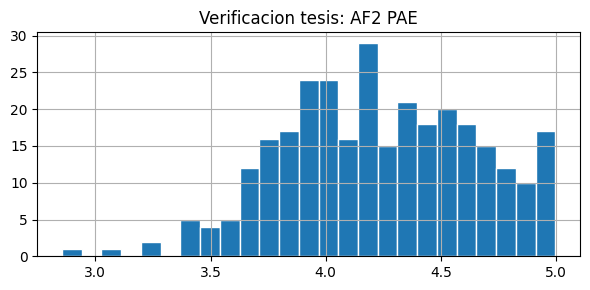

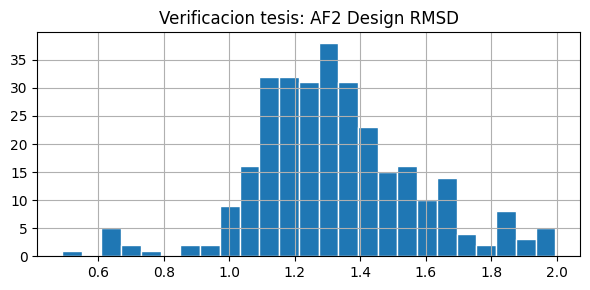

C:\Users\PC\AppData\Local\Temp\ipykernel_18760\3729303692.py:27: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  accepted[col].dropna().hist(ax=ax, bins=25, edgecolor="white")


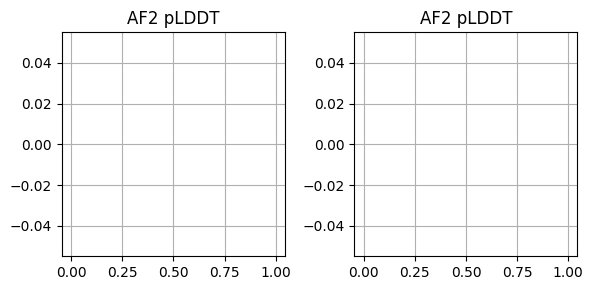

In [14]:
# Verificacion: tablas por pool y metricas desde backend OVO
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

ovo_home = os.environ.get("OVO_HOME")
if not ovo_home:
    print("OVO_HOME no definido. Omitiendo verificacion.")
else:
    from ovo import db
    from ovo.core.logic import descriptor_logic, design_logic, project_logic
    project = project_logic.get_or_create_project("OVO Publication Examples 1")
    round_ids = list(db.Round.select_values("id", project_id=project.id))
    pool_ids = list(db.Pool.select_values("id", round_id__in=round_ids))
    designs = db.Design.select_dataframe(pool_id__in=pool_ids)
    desc = descriptor_logic.get_wide_descriptor_table(pool_ids=pool_ids)
    df = designs.join(desc)
    accepted = df[df.get("accepted", pd.Series(dtype=bool))] if "accepted" in df.columns else df
    print("Total disenos:", len(df), "| Aceptados:", len(accepted), "| Pools:", len(pool_ids))
    by_pool = df.groupby("pool_id").size().to_frame("total")
    if "accepted" in df.columns:
        by_pool["aceptados"] = df.groupby("pool_id")["accepted"].sum()
    print(by_pool)
    for col in ["AF2 PAE", "AF2 Design RMSD", "AF2 pLDDT"]:
        if col in df.columns:
            fig, ax = plt.subplots(figsize=(6, 3))
            accepted[col].dropna().hist(ax=ax, bins=25, edgecolor="white")
            ax.set_title(f"Verificacion tesis: {col}")
            plt.tight_layout()
            plt.show()